In [1]:
import matplotlib.pyplot as plt
import pennylane as qp
from pennylane import numpy as np

import torch


from importlib import reload


In [89]:
import functions
reload(functions)


<module 'functions' from '/home/tardant/Bureau/pennylane/Circuits_training/functions.py'>

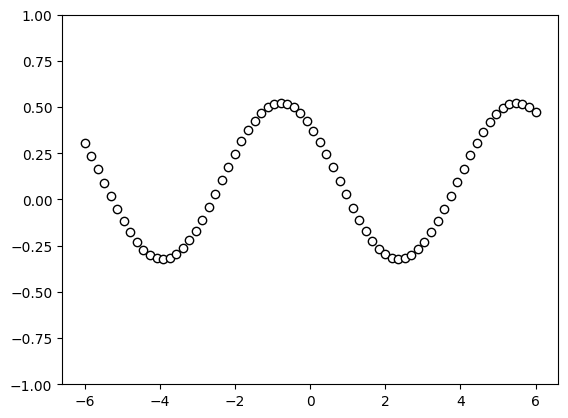

In [3]:
np.random.seed(456)


degree = 1  # degree of the target function
coeffs = [0.15 + 0.15j] * degree  # coefficients of non-zero frequencies
coeff0 = 0.1  # coefficient of zero frequency


def target_function(x):
    x_c = x.to(torch.complex64)
    """Generate a truncated Fourier series, where the data gets re-scaled."""
    res = torch.full_like(x_c, fill_value=coeff0, dtype=torch.complex64)
    for idx, coeff in enumerate(coeffs):
        k = idx + 1
        coeff_t = torch.as_tensor(coeff, dtype=torch.complex64, device=x.device)
        exponent = 1j * k * x_c
        res = res + coeff_t * torch.exp(exponent) + torch.conj(coeff_t) * torch.exp(-exponent)

    return torch.real(res)

x = torch.linspace(-6, 6, 70, requires_grad=False)

target_y = target_function(x)

plt.scatter(x, target_y, facecolor="white", edgecolor="black")
plt.ylim(-1, 1)
plt.show()

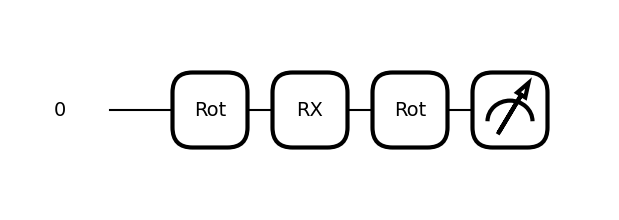

In [4]:
dev = qp.device("default.qubit", wires=1)


def S(x):
    """Data-encoding circuit block."""
    qp.RX(x, wires=0)


def W(theta):
    """Trainable circuit block."""
    qp.Rot(theta[0], theta[1], theta[2], wires=0)


@qp.qnode(dev, interface="torch")
def serial_quantum_model(weights, x):

    for theta in weights[:-1]:
        W(theta)
        S(x)

    # (L+1)'th unitary
    W(weights[-1])

    return qp.expval(qp.PauliZ(wires=0))


r = 1  # number of times the encoding gets repeated (here equal to the number of layers)
weights = (
    2 * np.pi * torch.rand((r + 1, 3), dtype=torch.float32, requires_grad=True)
)  # some random initial weights

x = np.linspace(-6, 6, 70, requires_grad=False)
x = torch.tensor(x, dtype=torch.float32, requires_grad=False)
random_quantum_model_y = serial_quantum_model(weights, x)

qp.draw_mpl(serial_quantum_model, level="device")(weights,1)
plt.show()

In [5]:
serial_quantum_model(weights, x[0])

tensor(0.9489, dtype=torch.float64, grad_fn=<DotBackward0>)

In [6]:
trained_weights, cst = functions.train(serial_quantum_model, weights, x, target_y, max_steps=100, batch_size=25)


Cost at step  10: 0.02661605124531187
Cost at step  20: 0.008988209519699447
Cost at step  30: 0.002072727171892798
Cost at step  40: 0.0003295470338946713
Cost at step  50: 0.0006858003633427391
Cost at step  60: 0.0001909922511183428
Cost at step  70: 5.314540340876965e-05
Cost at step  80: 2.9010092013412018e-05
Cost at step  90: 1.8992069611683096e-06
Cost at step 100: 3.786796708961712e-06


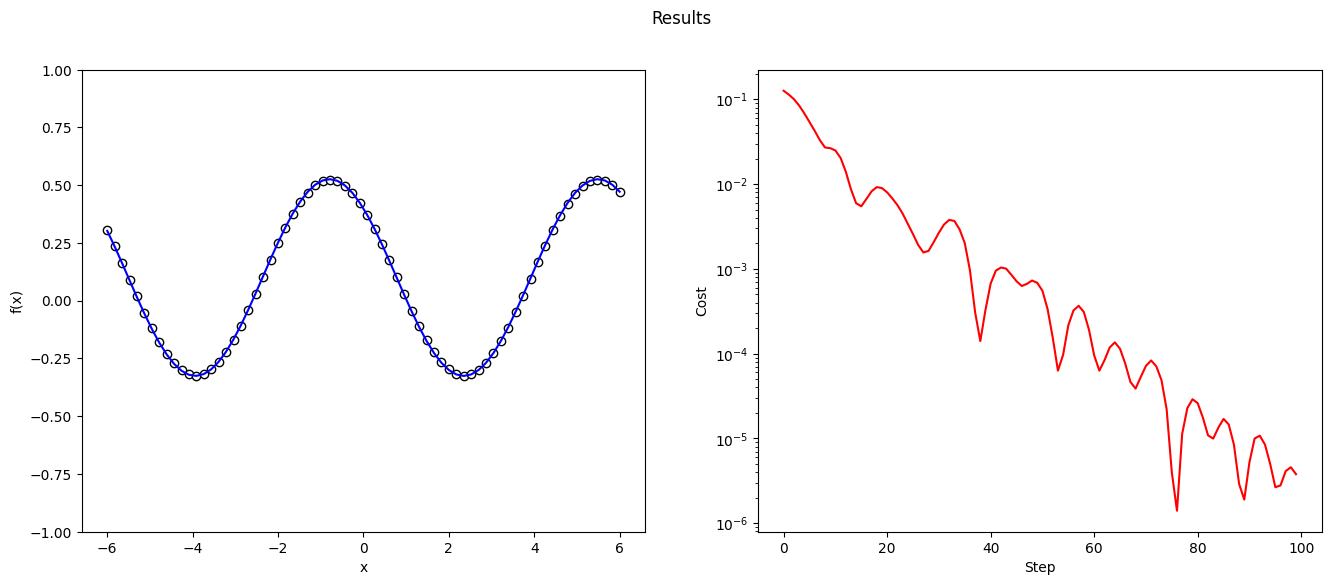

In [8]:
functions.show_results(serial_quantum_model,trained_weights, x, target_y, cst)

# Lets Get serious

In [9]:
from pennylane.templates import StronglyEntanglingLayers

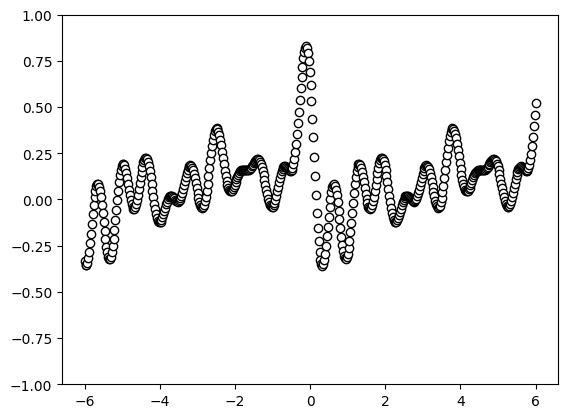

In [93]:

degree = 10  # degree of the target function
scaling = 1  # scaling of the data
coeffs = np.random.random(size=degree) + 1j * np.random.random(size=degree)  # coefficients of non-zero frequencies
# nomralize the coefficients so that the sum of the absolute values of the coefficients is 1
coeff0 = 0.1  # coefficient of zero frequency
coeffs = coeffs / np.sum(np.abs(coeffs))
coeffs = coeffs * (1 - coeff0) / 2  # scale the coefficients so that the sum of the absolute values of the coefficients is 1


dataset_size = 500
x = torch.linspace(-6, 6, dataset_size, requires_grad=False)
target_y = target_function(x)

plt.scatter(x, target_y, facecolor="white", edgecolor="black")
plt.ylim(-1, 1)
plt.show()

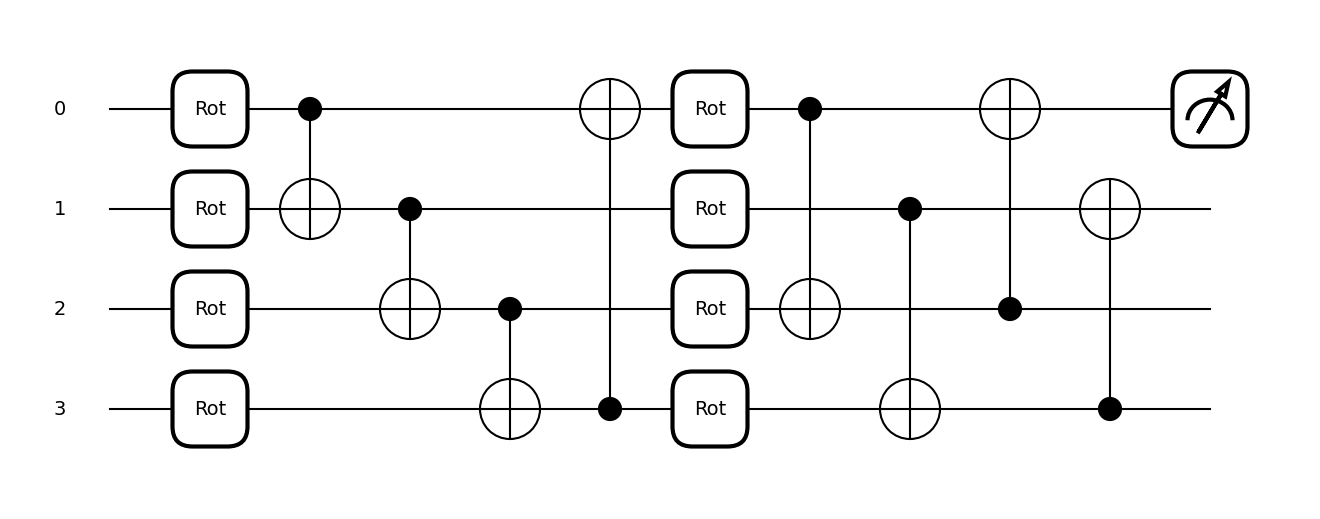

In [94]:
n_ansatz_layers = 2
n_qubits = 4

dev = qp.device("default.qubit", wires=4)


@qp.qnode(dev)
def ansatz(weights):
    StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qp.expval(qp.Identity(wires=0))


weights_ansatz = 2 * torch.pi * torch.rand((n_ansatz_layers, n_qubits, 3))
qp.draw_mpl(ansatz, level="device")(weights_ansatz)
plt.show()


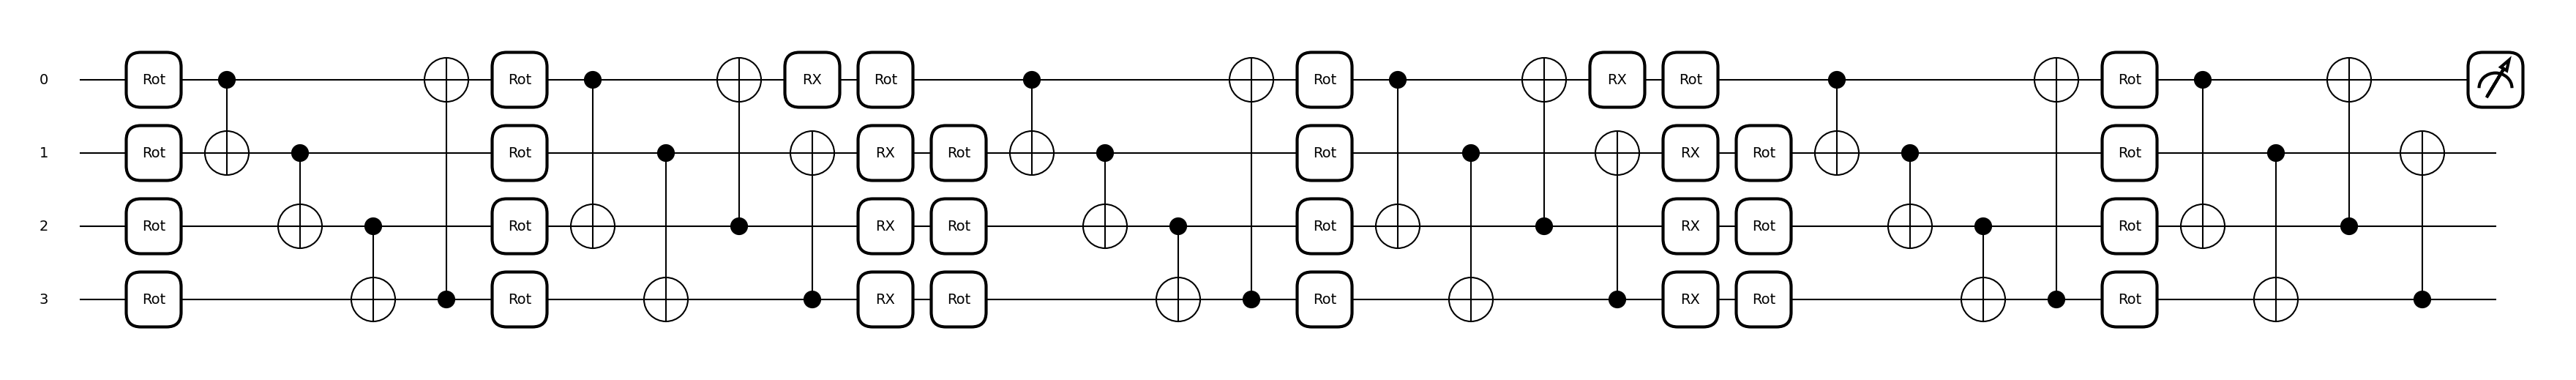

In [95]:
scaling = 1

dev = qp.device("default.qubit", wires=n_qubits)


def S(x):
    """Data-encoding circuit block."""
    for w in range(n_qubits):
        qp.RX(scaling * x, wires=w)


def W(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(n_qubits))


@qp.qnode(dev)
def parallel_quantum_model(weights, x):
    (layers,trainable_block_layers,qubits,_) = weights.shape
    layers = layers - 1
    W(weights[0])
    for l in range(layers):
        S(x*(l+1))
        W(weights[l+1])

    return qp.expval(qp.PauliZ(wires=0))

trainable_block_layers = 2
weights = 2 * torch.pi * torch.rand((3, trainable_block_layers, n_qubits, 3), requires_grad=True)
qp.draw_mpl(parallel_quantum_model, level="device")(weights,0)
plt.show()


torch.Size([500])


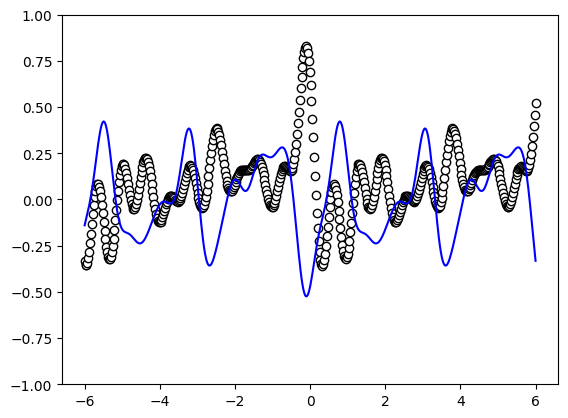

In [96]:

random_quantum_model_y = parallel_quantum_model(weights, x)
print(random_quantum_model_y.shape)
plt.plot(x, random_quantum_model_y.detach().numpy(), c="blue")
plt.scatter(x, target_y, facecolor="white", edgecolor="black")
plt.ylim(-1, 1)
plt.show()


In [98]:
weights, cst = functions.train(parallel_quantum_model,weights, x, target_y, max_steps=300, display_step=10)


Cost at step  10: 0.011037457949720178
Cost at step  20: 0.013626955585155422
Cost at step  30: 0.008078125103469795
Cost at step  40: 0.00515816047744986
Cost at step  50: 0.0026824864935179153
Cost at step  60: 0.002817985474069863
Cost at step  70: 0.0022561829237122575
Cost at step  80: 0.0010479088590499288
Cost at step  90: 0.0014405934636461378
Cost at step 100: 0.0010829294726067706
Cost at step 110: 0.001106428371744819
Cost at step 120: 0.0006497028269622966
Cost at step 130: 0.0004306173763994809
Cost at step 140: 0.000542499869265195
Cost at step 150: 0.00041010553987005775
Cost at step 160: 0.00039901154979508197
Cost at step 170: 0.0006173131890768104
Cost at step 180: 0.00019967170060026932
Cost at step 190: 0.00012019989368034857
Cost at step 200: 2.8005150804258502e-05
Cost at step 210: 3.4886890136028564e-05
Cost at step 220: 2.4568766809759667e-05
Cost at step 230: 2.2990511500502427e-05
Cost at step 240: 2.4953296789417376e-05
Cost at step 250: 2.656753641793435e-05

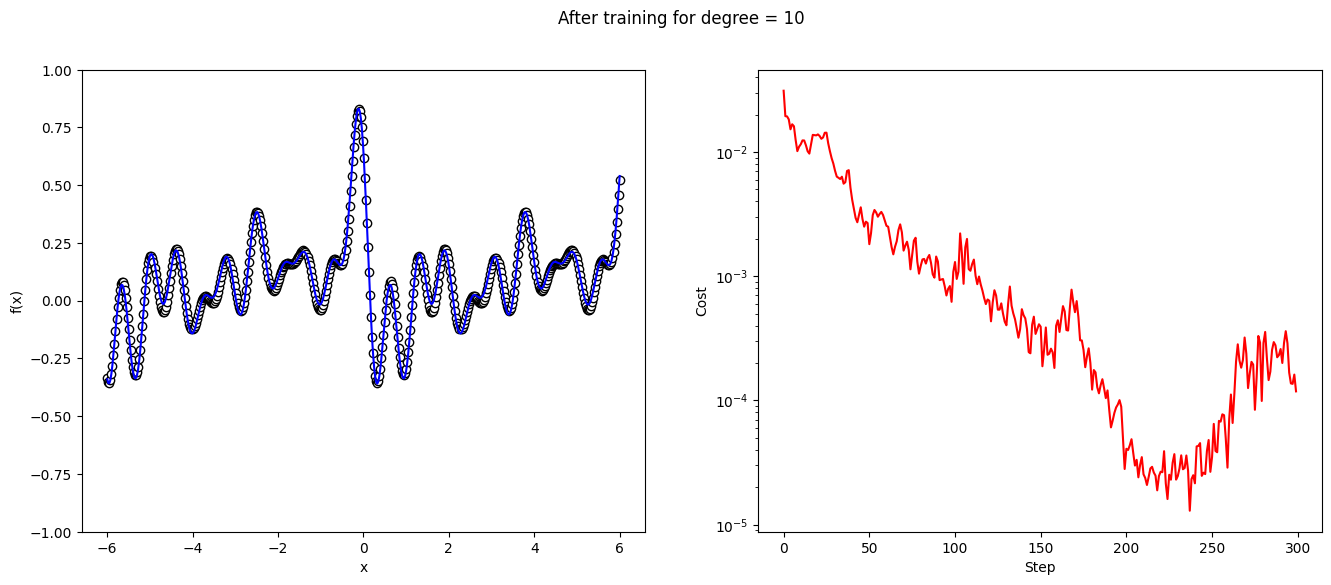

In [99]:
functions.show_results(parallel_quantum_model,weights, x, target_y, cst, title=f"After training for degree = {degree}")